In [1]:
# Lab7b 실습: Classical MLP와 Quantum Variational Regression 모델 비교.
# MLP, RY+CNOT ansatz, IQPEmbedding + StronglyEntanglingLayers 모델을 학습하여
# 동일한 회귀 문제(y = x1 * x2)를 해결한다.
# 학습 과정은 실시간 그래프로 시각화되며
# 모델 수렴 과정, 예측 정확도, 파라미터 수, test MSE를 비교한다.

# !pip install pennylane koreanize_matplotlib -q

import pennylane as qml
from pennylane import numpy as np
import numpy as std_np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import koreanize_matplotlib
from IPython.display import clear_output

plt.rcParams['axes.unicode_minus'] = False

In [2]:
# ============================================================
# ===== 수정 영역 =====
# ============================================================

n_layers = 2
epochs = 50  # 80  
lr = 0.01

In [3]:
# ============================================================
# 데이터 생성
# ============================================================

x1 = std_np.array([2*i + 1 for i in range(50)], dtype=float)
x2 = std_np.array([2*(i+1) for i in range(50)], dtype=float)

y = x1 * x2
THEORY_SUM = 169150


def scale_x(x):
    return (x - 1) / 99 * std_np.pi


Y_MIN = 2.0
Y_MAX = 9900.0


def scale_y(y_val):
    return (y_val - Y_MIN) / (Y_MAX - Y_MIN)


def unscale_y(y_sc):
    return y_sc * (Y_MAX - Y_MIN) + Y_MIN


x1_sc = scale_x(x1)
x2_sc = scale_x(x2)
y_sc = scale_y(y)

In [4]:
# ============================================================
# train/test 분할
# ============================================================

std_np.random.seed(42)

idx = std_np.random.permutation(50)

n_train = 35

idx_train = idx[:n_train]
idx_test = idx[n_train:]

print("="*60)
print("lab7b: MLP vs Quantum Regression 비교")
print("="*60)


# ============================================================
# Device
# ============================================================

dev = qml.device("default.qubit", wires=2)

lab7b: MLP vs Quantum Regression 비교


In [5]:
# ============================================================
# 모델 정의
# ============================================================

class MLP(nn.Module):

    def __init__(self):

        super().__init__()

        self.net = nn.Sequential(
            nn.Linear(2,3),
            nn.Tanh(),
            nn.Linear(3,1),
            nn.Sigmoid()
        )

    def forward(self,x):

        return self.net(x).squeeze()


@qml.qnode(dev)
def vqr_basic(inputs, weights):

    qml.RY(inputs[0], wires=0)
    qml.RY(inputs[1], wires=1)

    qml.CNOT(wires=[0,1])

    for l in range(n_layers):

        qml.RY(weights[l,0], wires=0)
        qml.RY(weights[l,1], wires=1)

        qml.CNOT(wires=[0,1])

    return qml.expval(qml.PauliZ(0))


@qml.qnode(dev)
def vqr_iqp(inputs, weights):

    qml.IQPEmbedding(inputs, wires=[0,1], n_repeats=1)

    qml.StronglyEntanglingLayers(weights, wires=[0,1])

    return qml.expval(qml.PauliZ(0))

In [6]:
# ============================================================
# 파라미터 수 계산
# ============================================================

n_params_mlp = sum(p.numel() for p in MLP().parameters())

n_params_basic = n_layers * 2

w_shape = qml.StronglyEntanglingLayers.shape(
    n_layers=n_layers,
    n_wires=2
)

n_params_iqp = int(std_np.prod(w_shape))


print("모델 파라미터")

print(f"MLP      : {n_params_mlp}")
print(f"RY+CNOT  : {n_params_basic}")
print(f"IQP+SEL  : {n_params_iqp}")

모델 파라미터
MLP      : 13
RY+CNOT  : 4
IQP+SEL  : 12


In [7]:
# ============================================================
# 공통 Quantum 함수
# ============================================================

def qml_cost(circuit, weights):

    loss = 0

    for i in idx_train:

        inp = np.array([x1_sc[i], x2_sc[i]])

        pred = (circuit(inp, weights) + 1)/2

        loss += (pred - y_sc[i])**2

    return loss / n_train


def qml_predict(circuit, weights):

    preds = []

    for i in range(50):

        inp = np.array([x1_sc[i], x2_sc[i]])

        p_sc = (float(circuit(inp, weights)) + 1)/2

        preds.append(unscale_y(p_sc))

    return std_np.array(preds)

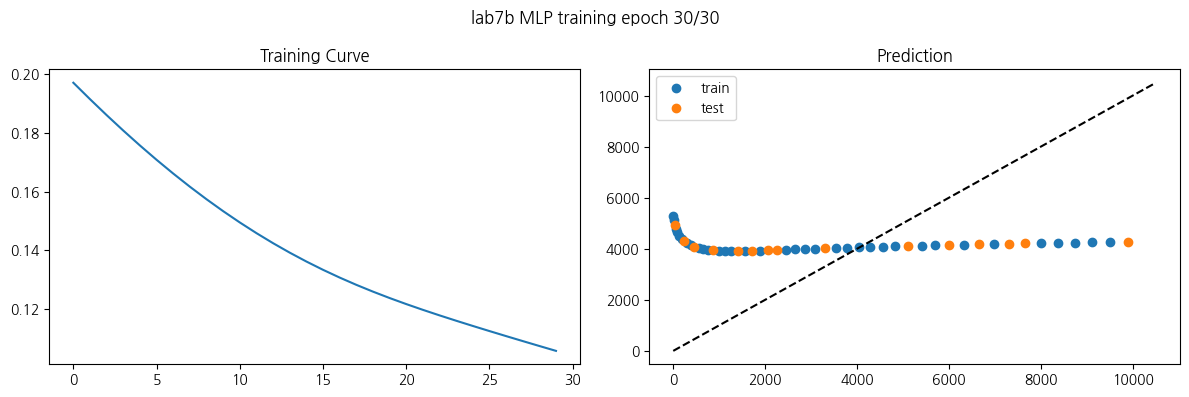

In [8]:
# ============================================================
# MLP 학습 (실시간 시각화)
# ============================================================

print("\n[1/3] MLP 학습")

X_train_t = torch.tensor(
    std_np.column_stack([x1_sc[idx_train], x2_sc[idx_train]]),
    dtype=torch.float32
)

y_train_t = torch.tensor(y_sc[idx_train], dtype=torch.float32)

X_all_t = torch.tensor(
    std_np.column_stack([x1_sc, x2_sc]),
    dtype=torch.float32
)

torch.manual_seed(42)

mlp = MLP()

optimizer = torch.optim.Adam(mlp.parameters(), lr=lr)

criterion = nn.MSELoss()

hist_mlp = []

for ep in range(epochs):

    optimizer.zero_grad()

    pred = mlp(X_train_t)

    loss = criterion(pred, y_train_t)

    loss.backward()

    optimizer.step()

    hist_mlp.append(loss.item())

    if ep % 5 == 0 or ep == epochs-1:

        clear_output(wait=True)

        with torch.no_grad():
            preds_now = mlp(X_all_t).numpy()*(Y_MAX-Y_MIN)+Y_MIN

        fig, (ax1,ax2) = plt.subplots(1,2, figsize=(12,4))

        fig.suptitle(f"lab7b MLP training epoch {ep+1}/{epochs}")

        ax1.plot(hist_mlp)

        ax1.set_title("Training Curve")

        ax2.scatter(y[idx_train],preds_now[idx_train],label="train")

        ax2.scatter(y[idx_test],preds_now[idx_test],label="test")

        ax2.plot([0,10500],[0,10500],'k--')

        ax2.set_title("Prediction")

        ax2.legend()

        plt.tight_layout()

        plt.show()


with torch.no_grad():
    mlp_preds = mlp(X_all_t).numpy()*(Y_MAX-Y_MIN)+Y_MIN

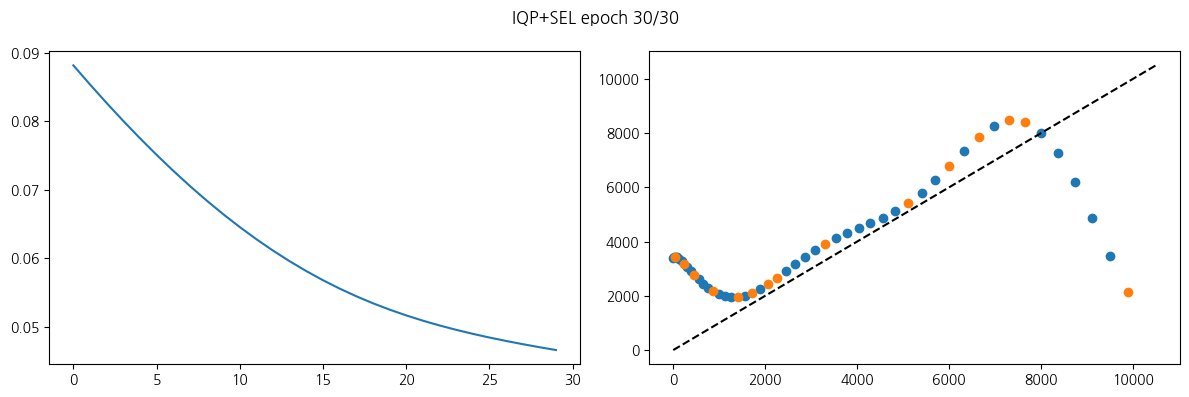

In [9]:
# ============================================================
# Quantum 학습
# ============================================================

def qml_train(circuit, weights, label):

    opt = qml.AdamOptimizer(stepsize=lr)

    history = []

    for ep in range(epochs):

        weights = opt.step(lambda w: qml_cost(circuit,w), weights)

        loss = float(qml_cost(circuit,weights))

        history.append(loss)

        if ep % 5 == 0 or ep == epochs-1:

            clear_output(wait=True)

            preds_now = qml_predict(circuit,weights)

            fig,(ax1,ax2)=plt.subplots(1,2,figsize=(12,4))

            fig.suptitle(f"{label} epoch {ep+1}/{epochs}")

            ax1.plot(history)

            ax2.scatter(y[idx_train],preds_now[idx_train])

            ax2.scatter(y[idx_test],preds_now[idx_test])

            ax2.plot([0,10500],[0,10500],'k--')

            plt.tight_layout()

            plt.show()

    return weights,history


print("\n[2/3] RY+CNOT 학습")

w_basic = np.array(
    std_np.random.uniform(0,std_np.pi,(n_layers,2)),
    requires_grad=True
)

w_basic,hist_basic = qml_train(vqr_basic,w_basic,"RY+CNOT")

preds_basic = qml_predict(vqr_basic,w_basic)


print("\n[3/3] IQP+SEL 학습")

w_iqp = np.array(
    std_np.random.uniform(0,std_np.pi,w_shape),
    requires_grad=True
)

w_iqp,hist_iqp = qml_train(vqr_iqp,w_iqp,"IQP+SEL")

preds_iqp = qml_predict(vqr_iqp,w_iqp)

In [10]:
# ============================================================
# 결과 비교
# ============================================================

sum_mlp = mlp_preds.sum()
sum_basic = preds_basic.sum()
sum_iqp = preds_iqp.sum()

mse_mlp = std_np.mean((mlp_preds[idx_test]-y[idx_test])**2)
mse_basic = std_np.mean((preds_basic[idx_test]-y[idx_test])**2)
mse_iqp = std_np.mean((preds_iqp[idx_test]-y[idx_test])**2)


print("\n최종 결과")

print(f"MLP      sum={sum_mlp:.1f}   MSE={mse_mlp:.2f}")
print(f"RY+CNOT  sum={sum_basic:.1f} MSE={mse_basic:.2f}")
print(f"IQP+SEL  sum={sum_iqp:.1f}   MSE={mse_iqp:.2f}")

print("\nlab7b 완료!")


최종 결과
MLP      sum=208790.0   MSE=9668845.71
RY+CNOT  sum=288986.5 MSE=8371749.23
IQP+SEL  sum=205757.7   MSE=6165086.03

lab7b 완료!
